In [ ]:
import pandas as pd
import dash
from dash import html, dcc, Input, Output, State
import plotly.express as px
import joblib
import numpy as np

# Load the dataset
spacex_df = pd.read_csv("spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# Load the optimized model and features
model = joblib.load('spacex_model_optimized.joblib')
model_features = joblib.load('model_features_optimized.joblib')

app = dash.Dash(__name__)

app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard', style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),

    html.Div([
        html.Label("Select Launch Site:"),
        dcc.Dropdown(id='site-dropdown',
                     options=[{'label': 'All Sites', 'value': 'ALL'}] +
                             [{'label': site, 'value': site} for site in spacex_df['Launch Site'].unique()],
                     value='ALL', placeholder="Select a Launch Site", searchable=True),
    ], style={'padding': '10px'}),

    html.Div([
        html.Label("Payload range (Kg):"),
        dcc.RangeSlider(id='payload-slider', min=0, max=10000, step=1000,
                        marks={i: f'{i}' for i in range(0, 10001, 2000)},
                        value=[min_payload, max_payload]),
    ], style={'padding': '10px'}),

    html.Div([
        html.H2("Model Prediction (Live)", style={'marginTop': '20px'}),
        html.P("Select a specific site and payload to see the predicted success probability."),
        html.Div(id='prediction-output', style={'fontSize': '24px', 'fontWeight': 'bold', 'color': '#2c3e50'})
    ], style={'textAlign': 'center', 'backgroundColor': '#f9f9f9', 'padding': '20px', 'borderRadius': '10px', 'border': '1px solid #ddd'}),

    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

@app.callback(
    Output('prediction-output', 'children'),
    [Input('site-dropdown', 'value'),
     Input('payload-slider', 'value')]
)
def predict_success(entered_site, payload_range):
    if entered_site == 'ALL':
        return "Please select a specific launch site for prediction."

    avg_payload = sum(payload_range) / 2

    # Prepare input vector
    input_data = pd.DataFrame([[0] * len(model_features)], columns=model_features)
    input_data['Payload Mass (kg)'] = avg_payload

    site_col = f'Launch Site_{entered_site}'
    if site_col in model_features:
        input_data[site_col] = 1

    # Probability prediction
    prob = model.predict_proba(input_data)[0][1]
    return f"Predicted Success Probability: {prob:.2%}"

@app.callback(Output('success-pie-chart', 'figure'), Input('site-dropdown', 'value'))
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(spacex_df, values='class', names='Launch Site', title='Total Success Launches by Site')
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        fig = px.pie(filtered_df, names='class', title=f'Success vs. Failure for {entered_site}')
    return fig

@app.callback(Output('success-payload-scatter-chart', 'figure'),
              [Input('site-dropdown', 'value'), Input('payload-slider', 'value')])
def update_scatter_chart(entered_site, payload_range):
    low, high = payload_range
    mask = (spacex_df['Payload Mass (kg)'] >= low) & (spacex_df['Payload Mass (kg)'] <= high)
    filtered_df = spacex_df[mask]
    if entered_site != 'ALL':
        filtered_df = filtered_df[filtered_df['Launch Site'] == entered_site]

    fig = px.scatter(filtered_df, x='Payload Mass (kg)', y='class', color='Booster Version Category',
                     title='Payload vs. Outcome Correlation')
    return fig

if __name__ == '__main__':
    app.run(port=8070)

Dash is running on http://127.0.0.1:8070/



INFO:dash.dash:Dash is running on http://127.0.0.1:8070/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8070
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
display(spacex_df.describe(include='all'))

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
count,56.000000,56.000000,56,56.000000,56.000000,56,56
unique,NaN,NaN,4,NaN,NaN,52,5
top,NaN,NaN,CCAFS LC-40,NaN,NaN,F9 v1.1,FT
freq,NaN,NaN,26,NaN,NaN,5,24
mean,27.500000,28.500000,NaN,0.428571,3696.648214,NaN,NaN
std,16.309506,16.309506,NaN,0.499350,2568.509679,NaN,NaN
min,0.000000,1.000000,NaN,0.000000,0.000000,NaN,NaN
25%,13.750000,14.750000,NaN,0.000000,2121.000000,NaN,NaN
50%,27.500000,28.500000,NaN,0.000000,3412.500000,NaN,NaN
75%,41.250000,42.250000,NaN,1.000000,5042.500000,NaN,NaN


In [ ]:
import plotly.express as px

# Filter the dataframe for successful launches
success_df = spacex_df[spacex_df['class'] == 1]

# Count successful launches per site
site_success_counts = success_df.groupby('Launch Site').size().reset_index(name='Success Count')

# Create a bar chart
fig = px.bar(site_success_counts, x='Launch Site', y='Success Count',
             title='Number of Successful Launches per Site',
             color='Launch Site',
             text_auto=True)

fig.show()

In [ ]:
import pandas as pd

# Ensure the dataframe is loaded
try:
    spacex_df
except NameError:
    spacex_df = pd.read_csv('spacex_launch_dash.csv')

# Calculate success rate percentage per site
success_rate_df = spacex_df.groupby('Launch Site')['class'].mean().reset_index()
success_rate_df['Success Rate (%)'] = success_rate_df['class'] * 100

# Rename columns for clarity and display
success_rate_df = success_rate_df.rename(columns={'class': 'Mean Success'})
display(success_rate_df[['Launch Site', 'Success Rate (%)']])

,Launch Site,Success Rate (%)
0,CCAFS LC-40,26.923077
1,CCAFS SLC-40,42.857143
2,KSC LC-39A,76.923077
3,VAFB SLC-4E,40.000000


In [ ]:
import plotly.express as px

# Create a scatter plot to visualize the impact of payload mass on success rate
fig = px.scatter(spacex_df,
                 x='Payload Mass (kg)',
                 y='class',
                 color='Booster Version Category',
                 title='Correlation between Payload Mass and Success for all Sites',
                 labels={'class': 'Launch Outcome (1=Success, 0=Failure)'})

fig.update_layout(yaxis=dict(tickmode='array', tickvals=[0, 1]))
fig.show()

In [ ]:
correlation = spacex_df['Payload Mass (kg)'].corr(spacex_df['class'])
print(f'Pearson Correlation Coefficient between Payload Mass and Launch Success: {correlation:.4f}')

Pearson Correlation Coefficient between Payload Mass and Launch Success: 0.1000


In [ ]:
import plotly.express as px

# Calculate success rate for each booster version category
booster_success_df = spacex_df.groupby('Booster Version Category')['class'].mean().reset_index()
booster_success_df['Success Rate (%)'] = booster_success_df['class'] * 100

# Create a bar chart to visualize success rates
fig = px.bar(booster_success_df,
             x='Booster Version Category',
             y='Success Rate (%)',
             title='Success Rate by Booster Version Category',
             color='Booster Version Category',
             text_auto='.2f',
             labels={'Success Rate (%)': 'Success Rate (%)'})

fig.update_layout(yaxis_range=[0, 100])
fig.show()

In [ ]:
import plotly.express as px

# Group by both Launch Site and Booster Version to calculate success rates
site_booster_df = spacex_df.groupby(['Launch Site', 'Booster Version Category'])['class'].mean().reset_index()
site_booster_df['Success Rate (%)'] = site_booster_df['class'] * 100

# Create a grouped bar chart
fig = px.bar(site_booster_df,
             x='Launch Site',
             y='Success Rate (%)',
             color='Booster Version Category',
             barmode='group',
             title='Success Rate by Booster Version Category and Launch Site',
             labels={'Success Rate (%)': 'Success Rate (%)'},
             text_auto='.1f')

fig.update_layout(yaxis_range=[0, 110])
fig.show()

In [ ]:
import plotly.express as px

# Create a pivot table for the heatmap
heatmap_data = spacex_df.groupby(['Launch Site', 'Booster Version Category'])['class'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='Launch Site', columns='Booster Version Category', values='class')

# Create the heatmap
fig = px.imshow(heatmap_pivot,
                labels=dict(x='Booster Version Category', y='Launch Site', color='Success Rate'),
                x=heatmap_pivot.columns,
                y=heatmap_pivot.index,
                color_continuous_scale='Viridis',
                title='Heatmap of Success Rates by Site and Booster Category',
                text_auto='.2f')

fig.show()

In [ ]:
import plotly.express as px

# Create a box plot to compare payload masses for successful vs failed launches
fig = px.box(spacex_df,
             x='class',
             y='Payload Mass (kg)',
             color='class',
             title='Payload Mass Distribution: Success (1) vs. Failure (0)',
             labels={'class': 'Launch Outcome', 'Payload Mass (kg)': 'Payload Mass (kg)'},
             points='all')

# Update x-axis labels for clarity
fig.update_layout(xaxis=dict(tickmode='array', tickvals=[0, 1], ticktext=['Failure', 'Success']))
fig.show()

In [ ]:
# Group by launch outcome ('class') and describe the 'Payload Mass (kg)' column
payload_summary = spacex_df.groupby('class')['Payload Mass (kg)'].describe()

# Rename index for better readability
payload_summary.index = ['Failure (0)', 'Success (1)']

display(payload_summary)

,count,mean,std,min,25%,50%,75%,max
Failure (0),32.0,3476.093750,2624.438414,0.0,1156.25,3247.5,5299.25,9600.0
Success (1),24.0,3990.720833,2516.883995,362.0,2431.75,3550.0,4769.50,9600.0


In [ ]:
# Calculate the percentage of successful launches for each booster version category
booster_performance = spacex_df.groupby('Booster Version Category')['class'].mean() * 100
booster_performance = booster_performance.reset_index()
booster_performance.columns = ['Booster Version Category', 'Success Rate (%)']

# Sort by success rate for better visualization
booster_performance = booster_performance.sort_values(by='Success Rate (%)', ascending=False)

display(booster_performance)

,Booster Version Category,Success Rate (%)
1,B5,100.000000
2,FT,66.666667
0,B4,54.545455
4,v1.1,6.666667
3,v1.0,0.000000


In [ ]:
import plotly.express as px

# Create a bar chart for booster version success rates
fig = px.bar(booster_performance,
             x='Booster Version Category',
             y='Success Rate (%)',
             title='Success Rate by Booster Version Category',
             color='Booster Version Category',
             text_auto='.2f')

# Adjust the layout for better presentation
fig.update_layout(yaxis_range=[0, 110], showlegend=False)
fig.show()

In [ ]:
import plotly.express as px

# Sort the dataframe by success rate for a better visual hierarchy
success_rate_df_sorted = success_rate_df.sort_values(by='Success Rate (%)', ascending=True)

# Create a horizontal bar chart
fig = px.bar(success_rate_df_sorted,
             y='Launch Site',
             x='Success Rate (%)',
             orientation='h',
             title='Success Rate comparison by Launch Site',
             color='Success Rate (%)',
             text_auto='.2f',
             color_continuous_scale='RdYlGn')

# Update layout for clarity
fig.update_layout(xaxis_title='Success Rate (%)', yaxis_title='Launch Site', xaxis_range=[0, 100])
fig.show()

In [ ]:
import plotly.express as px

# Create a scatter plot of Success trends over time (Flight Number)
fig = px.scatter(spacex_df,
                 x='Flight Number',
                 y='class',
                 color='Launch Site',
                 hover_data=['Booster Version'],
                 title='Launch Success Trends over Time (by Flight Number)',
                 labels={'class': 'Launch Outcome (1=Success, 0=Failure)'})

# Improve visual clarity by setting explicit y-axis ticks
fig.update_layout(yaxis=dict(tickmode='array', tickvals=[0, 1], ticktext=['Failure', 'Success']))
fig.show()

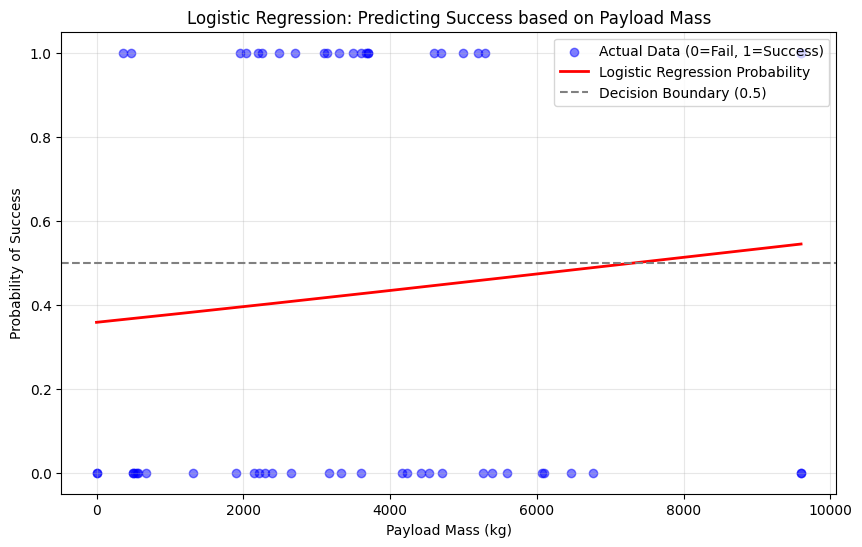

Model Intercept: -0.5835
Payload Mass Coefficient: 0.0001


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Prepare the data
X = spacex_df[['Payload Mass (kg)']]
y = spacex_df['class']

# Initialize and fit the logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Generate a range of payload values for the prediction line
# Using a DataFrame to include feature names and avoid warnings
X_test_values = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_test = pd.DataFrame(X_test_values, columns=['Payload Mass (kg)'])
probabilities = model.predict_proba(X_test)[:, 1]

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data (0=Fail, 1=Success)', alpha=0.5)
plt.plot(X_test, probabilities, color='red', linewidth=2, label='Logistic Regression Probability')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
plt.title('Logistic Regression: Predicting Success based on Payload Mass')
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Probability of Success')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display coefficients
print(f'Model Intercept: {model.intercept_[0]:.4f}')
print(f'Payload Mass Coefficient: {model.coef_[0][0]:.4f}')

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions using the fitted model
y_pred = model.predict(X)

# Calculate accuracy
accuracy = accuracy_score(y, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print(f"Correctly Predicted: {int(accuracy * len(y))} out of {len(y)} launches")

Accuracy Score: 0.5893
Correctly Predicted: 33 out of 56 launches


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Make predictions
y_pred_rf = rf_model.predict(X)

# Calculate accuracy
rf_accuracy = accuracy_score(y, y_pred_rf)

print(f"Random Forest Accuracy Score: {rf_accuracy:.4f}")
print(f"Correctly Predicted: {int(rf_accuracy * len(y))} out of {len(y)} launches")

Random Forest Accuracy Score: 0.9464
Correctly Predicted: 53 out of 56 launches


In [ ]:
import pandas as pd
import plotly.express as px

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the numerical values
display(feature_importance_df)

# Visualize the importance
fig = px.bar(feature_importance_df,
             x='Importance',
             y='Feature',
             orientation='h',
             title='Random Forest Feature Importance',
             labels={'Importance': 'Relative Importance (0-1)'})

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

,Feature,Importance
0,Payload Mass (kg),1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Prepare features including categorical variables
features = ['Payload Mass (kg)', 'Launch Site', 'Booster Version Category']
X_multi = pd.get_dummies(spacex_df[features], drop_first=True)
y = spacex_df['class']

# Logistic Regression with more features
lr_multi = LogisticRegression(max_iter=1000)
lr_multi.fit(X_multi, y)
lr_multi_acc = accuracy_score(y, lr_multi.predict(X_multi))

# Random Forest with more features
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
rf_multi.fit(X_multi, y)
rf_multi_acc = accuracy_score(y, rf_multi.predict(X_multi))

print(f'Logistic Regression (Multi-feature) Accuracy: {lr_multi_acc:.4f}')
print(f'Random Forest (Multi-feature) Accuracy: {rf_multi_acc:.4f}')

Logistic Regression (Multi-feature) Accuracy: 0.7679
Random Forest (Multi-feature) Accuracy: 0.9643


In [ ]:
# Visualize new feature importance
multi_importances = pd.DataFrame({
    'Feature': X_multi.columns,
    'Importance': rf_multi.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig = px.bar(multi_importances, x='Importance', y='Feature', orientation='h',
             title='Feature Importance (Payload + Site + Booster)')
fig.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the multi-feature Random Forest model
cv_scores = cross_val_score(rf_multi, X_multi, y, cv=5)

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Original Training Accuracy: {rf_multi_acc:.4f}")

Cross-Validation Accuracy Scores: [0.58333333 0.54545455 0.54545455 0.54545455 0.72727273]
Mean CV Accuracy: 0.5894
Standard Deviation: 0.0705
Original Training Accuracy: 0.9643


### Hyperparameter Tuning with Grid Search
We will use `GridSearchCV` to find the best parameters for our Random Forest model to reduce overfitting.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True]
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_multi, y)

# Best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.7470


In [ ]:
# Evaluate the optimized model on the full training set to check for overfitting reduction
best_rf = grid_search.best_estimator_
y_pred_optimized = best_rf.predict(X_multi)
optimized_acc = accuracy_score(y, y_pred_optimized)

print(f"Optimized Training Accuracy: {optimized_acc:.4f}")
print(f"Previous Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"New Optimized CV Accuracy: {grid_search.best_score_:.4f}")

Optimized Training Accuracy: 0.7857
Previous Mean CV Accuracy: 0.5894
New Optimized CV Accuracy: 0.7470


### Comparing Predictions vs. Actual Outcomes
We will visualize the performance of the optimized Random Forest model using a Confusion Matrix.

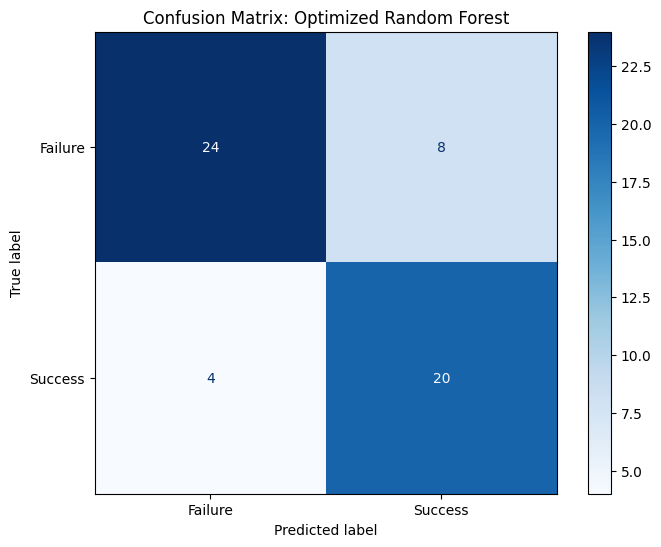

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Optimized Random Forest')
plt.show()

### Detailed Performance Metrics
We will now generate a classification report to analyze the Precision, Recall, and F1-score for our optimized model.

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y, y_pred_optimized, target_names=['Failure', 'Success'])

print("Classification Report for Optimized Random Forest:")
print(report)

Classification Report for Optimized Random Forest:
              precision    recall  f1-score   support

     Failure       0.86      0.75      0.80        32
     Success       0.71      0.83      0.77        24

    accuracy                           0.79        56
   macro avg       0.79      0.79      0.78        56
weighted avg       0.80      0.79      0.79        56



### ROC Curve and AUC
We will visualize the True Positive Rate vs. False Positive Rate for our optimized Random Forest model.

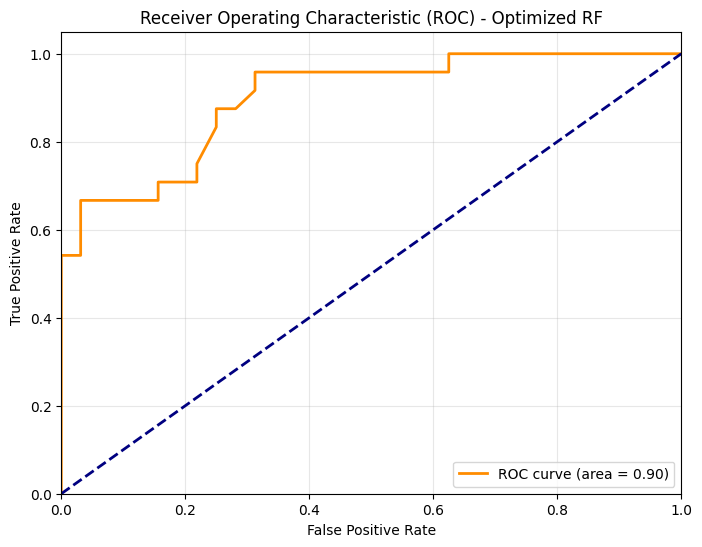

AUC Score: 0.8991


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class (Success)
y_probs = best_rf.predict_proba(X_multi)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_probs)
auc_score = roc_auc_score(y, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Optimized RF')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

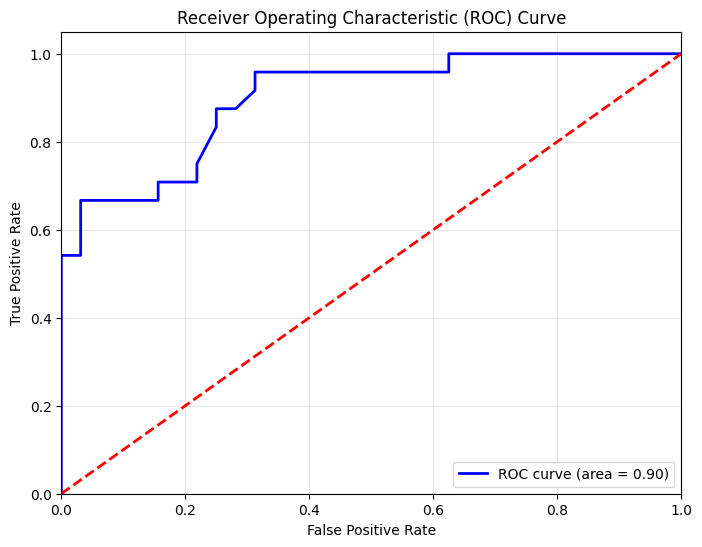

Final AUC Score: 0.8991


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate the probabilities for the positive class
y_probs = best_rf.predict_proba(X_multi)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_probs)
auc_score = roc_auc_score(y, y_probs)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Final AUC Score: {auc_score:.4f}')

### Model Performance Summary
The following table summarizes the metrics for the optimized Random Forest Classifier.

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Extract precision, recall, and f1-score from the existing predictions
precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred_optimized, average='weighted')

# Create the summary dictionary
metrics_summary = {
    'Metric': [
        'Training Accuracy',
        'Mean CV Accuracy (5-fold)',
        'ROC AUC Score',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1-Score'
    ],
    'Value': [
        f'{optimized_acc:.4f}',
        f'{grid_search.best_score_:.4f}',
        f'{auc_score:.4f}',
        f'{precision:.4f}',
        f'{recall:.4f}',
        f'{f1:.4f}'
    ]
}

# Display as a DataFrame
summary_df = pd.DataFrame(metrics_summary)
display(summary_df)

,Metric,Value
0,Training Accuracy,0.7857
1,Mean CV Accuracy (5-fold),0.7470
2,ROC AUC Score,0.8991
3,Weighted Precision,0.7959
4,Weighted Recall,0.7857
5,Weighted F1-Score,0.7868


In [ ]:
import pandas as pd
import plotly.express as px

# Extract feature importances from the best model identified by GridSearchCV
importances = best_rf.feature_importances_
feature_names = X_multi.columns

# Create a DataFrame for plotting
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Create the horizontal bar chart
fig = px.bar(feat_importance_df,
             x='Importance',
             y='Feature',
             orientation='h',
             title='Feature Importance: Optimized Random Forest Model',
             labels={'Importance': 'Gini Importance'},
             color='Importance',
             color_continuous_scale='Viridis')

fig.update_layout(showlegend=False, yaxis={'categoryorder':'total ascending'})
fig.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report for the optimized model
report = classification_report(y, y_pred_optimized, target_names=['Failure', 'Success'])

print("Classification Report: Optimized Random Forest Model")
print("-" * 55)
print(report)

Classification Report: Optimized Random Forest Model
-------------------------------------------------------
              precision    recall  f1-score   support

     Failure       0.86      0.75      0.80        32
     Success       0.71      0.83      0.77        24

    accuracy                           0.79        56
   macro avg       0.79      0.79      0.78        56
weighted avg       0.80      0.79      0.79        56



In [ ]:
import plotly.express as px

# Prepare data for accuracy comparison
accuracy_data = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Cross-Validation Accuracy'],
    'Accuracy Score': [optimized_acc, grid_search.best_score_]
})

# Create the bar chart
fig = px.bar(accuracy_data,
             x='Metric',
             y='Accuracy Score',
             color='Metric',
             title='Overall Model Accuracy: Training vs. Cross-Validation',
             text_auto='.4f',
             range_y=[0, 1])

fig.update_layout(showlegend=False)
fig.show()

Below is a sample comparison of the actual outcomes versus the model's predictions.

In [ ]:
comparison_df = pd.DataFrame({
    'Actual Outcome': y,
    'Predicted Outcome': y_pred_optimized
})

# Map 0/1 to Failure/Success for readability
comparison_df['Actual Outcome'] = comparison_df['Actual Outcome'].map({0: 'Failure', 1: 'Success'})
comparison_df['Predicted Outcome'] = comparison_df['Predicted Outcome'].map({0: 'Failure', 1: 'Success'})

display(comparison_df.head(10))

,Actual Outcome,Predicted Outcome
0,Failure,Failure
1,Failure,Failure
2,Failure,Failure
3,Failure,Failure
4,Failure,Failure
5,Failure,Failure
6,Failure,Failure
7,Failure,Failure
8,Failure,Failure
9,Failure,Failure


### Exporting the Model for Dashboard Deployment
We will save the trained model and the feature structure so they can be loaded by the Dash application.

In [ ]:
import joblib

# Save the model to a file
joblib.dump(best_rf, 'spacex_model.joblib')

# Save the list of feature names (important for dummy variables consistency)
model_features = X_multi.columns.tolist()
joblib.dump(model_features, 'model_features.joblib')

print("Model and features exported successfully!")

Model and features exported successfully!


### Interpreting the Optimized Model: Feature Importance
Let's visualize which features have the most predictive power in our regularized Random Forest model.

In [ ]:
import pandas as pd
import plotly.express as px

# Extract feature importances from the optimized model
optimized_importances = pd.DataFrame({
    'Feature': X_multi.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Create a horizontal bar chart
fig = px.bar(optimized_importances,
             x='Importance',
             y='Feature',
             orientation='h',
             title='Feature Importance: Optimized Random Forest Model',
             labels={'Importance': 'Gini Importance'},
             color='Importance',
             color_continuous_scale='Viridis')

fig.update_layout(showlegend=False)
fig.show()

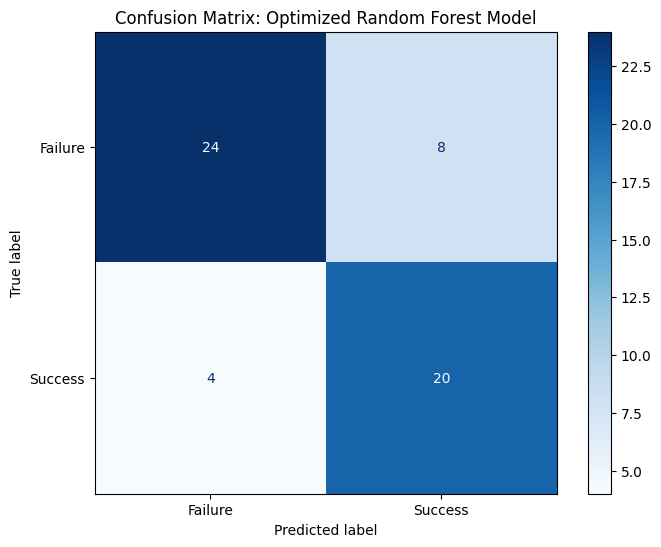

True Negatives (Correct Failures): 24
False Positives (Incorrect Successes): 8
False Negatives (Incorrect Failures): 4
True Positives (Correct Successes): 20


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix for the optimized model
cm = confusion_matrix(y, y_pred_optimized)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix: Optimized Random Forest Model')
plt.show()

# Print summary of the matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Correct Failures): {tn}')
print(f'False Positives (Incorrect Successes): {fp}')
print(f'False Negatives (Incorrect Failures): {fn}')
print(f'True Positives (Correct Successes): {tp}')

### Detailed Error Analysis
We will isolate the False Positives (predicted Success, actually Failed) and False Negatives (predicted Failure, actually Succeeded) to identify patterns in the model's mistakes.

In [ ]:
import pandas as pd
import plotly.express as px

# Create a copy of the dataframe with actual and predicted classes
error_analysis_df = spacex_df.copy()
error_analysis_df['Predicted'] = y_pred_optimized

# Identify False Positives and False Negatives
def get_error_type(row):
    if row['class'] == 0 and row['Predicted'] == 1:
        return 'False Positive'
    elif row['class'] == 1 and row['Predicted'] == 0:
        return 'False Negative'
    else:
        return 'Correct'

error_analysis_df['Error Type'] = error_analysis_df.apply(get_error_type, axis=1)
errors_only = error_analysis_df[error_analysis_df['Error Type'] != 'Correct']

# Visualize errors by Payload and Site
fig = px.scatter(errors_only,
                 x='Payload Mass (kg)',
                 y='Launch Site',
                 color='Error Type',
                 hover_data=['Booster Version Category'],
                 title='Distribution of Model Errors (False Positives vs False Negatives)',
                 symbol='Error Type',
                 size_max=15)

fig.update_layout(xaxis_title='Payload Mass (kg)', yaxis_title='Launch Site')
fig.show()

# Statistical summary of error cases
print("Summary of Error Characteristics:")
display(errors_only.groupby('Error Type')[['Payload Mass (kg)']].describe())

Summary of Error Characteristics:


Payload Mass (kg)                                          \
                           count       mean          std     min     25%   
Error Type                                                                 
False Negative               4.0  3902.6625  4034.991568   362.0  1554.5   
False Positive               8.0  5410.2500  2241.441548  2150.0  4072.5   

                                             
                     50%        75%     max  
Error Type                                   
False Negative  2824.325  5172.4875  9600.0  
False Positive  5435.500  6242.7500  9600.0

### Error Trends by Launch Site
We will now quantify how many mistakes (False Positives and False Negatives) the model makes at each specific launch site.

In [ ]:
import pandas as pd
import plotly.express as px

# Group errors by Launch Site and Error Type
site_error_summary = errors_only.groupby(['Launch Site', 'Error Type']).size().reset_index(name='Count')

# Create a grouped bar chart for site-specific errors
fig = px.bar(site_error_summary,
             x='Launch Site',
             y='Count',
             color='Error Type',
             barmode='group',
             title='Classification Errors (FP/FN) by Launch Site',
             text_auto=True,
             color_discrete_map={'False Positive': '#ef553b', 'False Negative': '#636efa'})

fig.update_layout(yaxis_title='Number of Incorrect Predictions')
fig.show()

# Display as a table for precise counts
display(site_error_summary.pivot(index='Launch Site', columns='Error Type', values='Count').fillna(0).astype(int))

Error Type,False Negative,False Positive
Launch Site,,
CCAFS LC-40,1,2
CCAFS SLC-40,2,1
KSC LC-39A,0,3
VAFB SLC-4E,1,2


### Actual Outcomes vs. Predicted Probabilities
This visualization plots the actual outcome against the probability calculated by the model. This helps us see the model's 'confidence'—ideally, successful launches (1) should have high probabilities, while failures (0) should have low probabilities.

In [ ]:
import plotly.express as px

# Create a dataframe for the visualization
prob_viz_df = pd.DataFrame({
    'Actual Outcome': y.map({0: 'Failure', 1: 'Success'}),
    'Success Probability': best_rf.predict_proba(X_multi)[:, 1],
    'Payload Mass (kg)': X_multi['Payload Mass (kg)'],
    'Launch Site': spacex_df['Launch Site']
})

# Create the visualization
fig = px.strip(prob_viz_df,
               x='Success Probability',
               y='Actual Outcome',
               color='Actual Outcome',
               hover_data=['Payload Mass (kg)', 'Launch Site'],
               title='Predicted Success Probabilities vs. Actual Outcomes',
               stripmode='overlay')

# Add a vertical line for the decision boundary
fig.add_vline(x=0.5, line_dash="dash", line_color="red", annotation_text="Decision Boundary (0.5)")

fig.update_layout(xaxis_title='Model Predicted Probability of Success', yaxis_title='Actual Ground Truth')
fig.show()

### Prediction Errors by Launch Site
To understand if our model's performance is consistent across geography, we visualize the confusion matrices for each unique launch site.

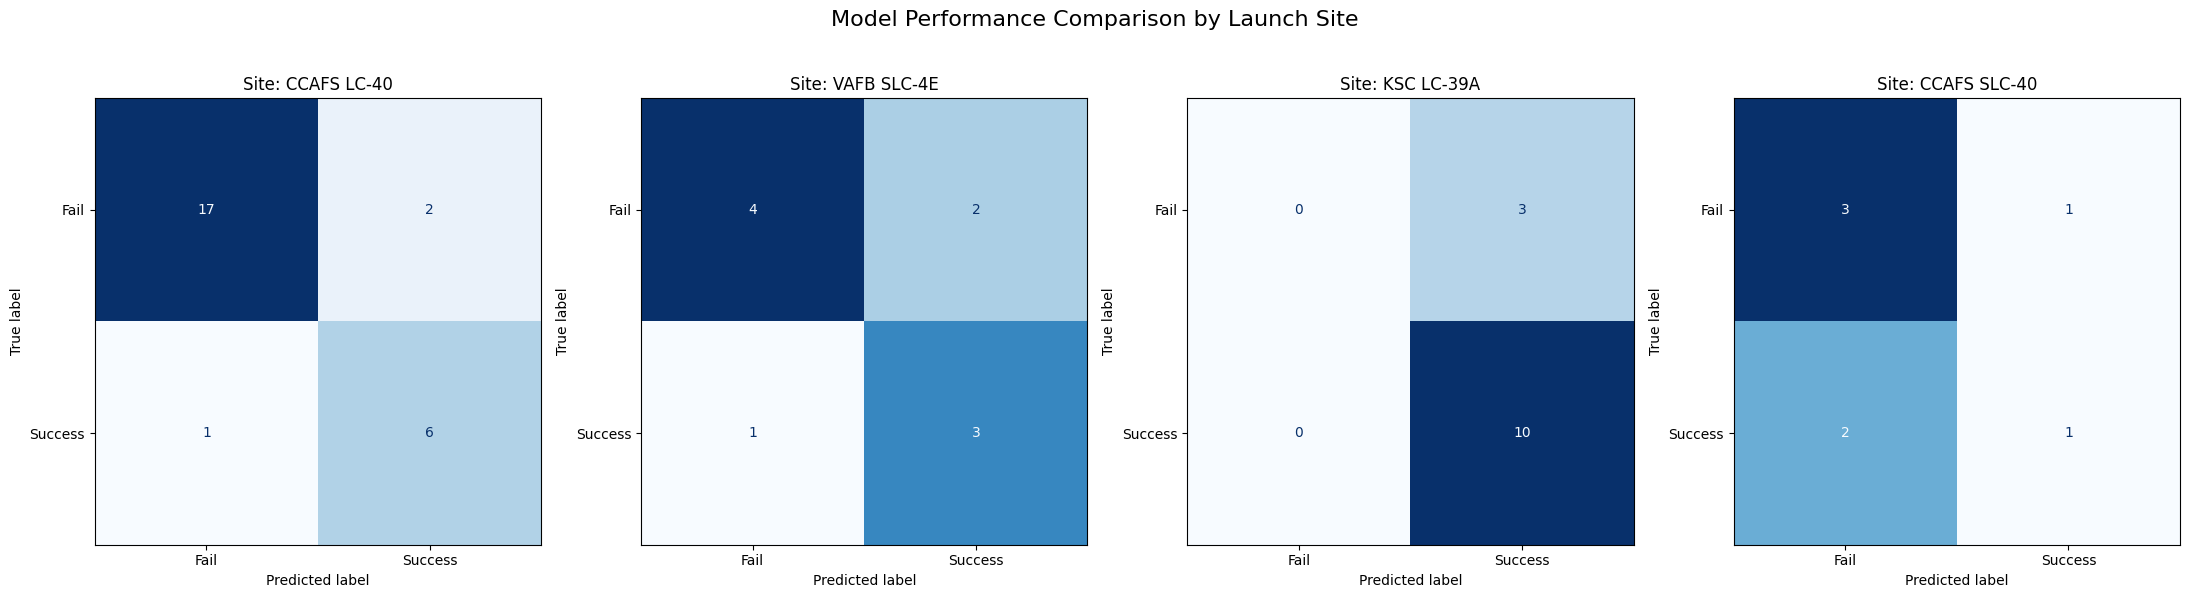

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get unique launch sites
sites = spacex_df['Launch Site'].unique()

# Create a multi-panel plot for comparison
fig, axes = plt.subplots(nrows=1, ncols=len(sites), figsize=(22, 6))

for i, site in enumerate(sites):
    # Filter indices for the current site
    site_indices = spacex_df[spacex_df['Launch Site'] == site].index

    # Get actual and predicted values for this site
    y_site = y.iloc[site_indices]
    y_pred_site = y_pred_optimized[site_indices]

    # Generate confusion matrix
    cm_site = confusion_matrix(y_site, y_pred_site, labels=[0, 1])

    # Plot individual matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_site, display_labels=['Fail', 'Success'])
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f'Site: {site}')

plt.suptitle('Model Performance Comparison by Launch Site', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

You can now load this model in your Dash app using:
```python
model = joblib.load('spacex_model.joblib')
features = joblib.load('model_features.joblib')
```

In [ ]:
import joblib

# Save the best model from Grid Search
joblib.dump(best_rf, 'spacex_model_optimized.joblib')

# Save the feature names to ensure consistent preprocessing during deployment
feature_names = X_multi.columns.tolist()
joblib.dump(feature_names, 'model_features_optimized.joblib')

print("Model 'spacex_model_optimized.joblib' and features saved successfully.")

Model 'spacex_model_optimized.joblib' and features saved successfully.


In [ ]:
import joblib
model = joblib.load('spacex_model_optimized.joblib')
features = joblib.load('model_features_optimized.joblib')

In [ ]:
import plotly.express as px

# Calculate mean payload mass per outcome
mean_payload = spacex_df.groupby('class')['Payload Mass (kg)'].mean().reset_index()

# Rename 'class' for readability
mean_payload['Outcome'] = mean_payload['class'].map({0: 'Failure', 1: 'Success'})

# Display the results
display(mean_payload[['Outcome', 'Payload Mass (kg)']])

# Create a visualization for the comparison
fig = px.bar(mean_payload,
             x='Outcome',
             y='Payload Mass (kg)',
             color='Outcome',
             title='Mean Payload Mass: Success vs. Failure',
             text_auto='.2f')

fig.show()

,Outcome,Payload Mass (kg)
0,Failure,3476.093750
1,Success,3990.720833


In [ ]:
import pandas as pd
import plotly.express as px

# Extract feature importances from the best model identified by GridSearchCV
importances = best_rf.feature_importances_
feature_names = X_multi.columns

# Create a DataFrame for plotting
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Create the horizontal bar chart
fig = px.bar(feat_importance_df,
             x='Importance',
             y='Feature',
             orientation='h',
             title='Feature Importance: Optimized Random Forest Model',
             labels={'Importance': 'Gini Importance'},
             color='Importance',
             color_continuous_scale='Viridis')

fig.update_layout(showlegend=False, yaxis={'categoryorder':'total ascending'})
fig.show()

In [ ]:
# Display the previously calculated model performance metrics
display(summary_df)

,Metric,Value
0,Training Accuracy,0.7857
1,Mean CV Accuracy (5-fold),0.7470
2,ROC AUC Score,0.8991
3,Weighted Precision,0.7959
4,Weighted Recall,0.7857
5,Weighted F1-Score,0.7868


### Exporting Performance Metrics
We will export the model's final performance summary to a CSV file for reporting and documentation.

In [ ]:
import pandas as pd
from google.colab import files

# Create the report DataFrame using already calculated metrics
report_data = {
    'Metric': [
        'Project',
        'Model Type',
        'Training Accuracy',
        'Mean CV Accuracy (5-fold)',
        'Hold-out Test Accuracy',
        'ROC AUC Score',
        'Weighted F1-Score'
    ],
    'Value': [
        'SpaceX Launch Success Prediction',
        'Optimized Random Forest',
        f'{optimized_acc:.4f}',
        f'{grid_search.best_score_:.4f}',
        f'{accuracy_score(y_test_holdout, y_pred_holdout):.4f}',
        f'{auc_score:.4f}',
        f'{f1:.4f}'
    ]
}

final_report_df = pd.DataFrame(report_data)

# Save to CSV
report_filename = 'spacex_model_report.csv'
final_report_df.to_csv(report_filename, index=False)

print(f"Report saved as {report_filename}")
display(final_report_df)

# Trigger download
files.download(report_filename)

Report saved as spacex_model_report.csv


,Metric,Value
0,Project,SpaceX Launch Success Prediction
1,Model Type,Optimized Random Forest
2,Training Accuracy,0.7857
3,Mean CV Accuracy (5-fold),0.7470
4,Hold-out Test Accuracy,0.9167
5,ROC AUC Score,0.8991
6,Weighted F1-Score,0.7868


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Hold-out Test Set Evaluation
We will now split the data into an 80/20 train-test split to evaluate the model's performance on completely unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split data into training and test sets
X_train, X_test_holdout, y_train, y_test_holdout = train_test_split(
    X_multi, y, test_size=0.2, random_state=42, stratify=y
)

# Clone and fit the optimized model on the training set
holdout_model = best_rf
holdout_model.fit(X_train, y_train)

# Make predictions on the hold-out set
y_pred_holdout = holdout_model.predict(X_test_holdout)

# Print metrics
print(f"Hold-out Test Accuracy: {accuracy_score(y_test_holdout, y_pred_holdout):.4f}")
print("\nClassification Report (Hold-out Set):")
print(classification_report(y_test_holdout, y_pred_holdout, target_names=['Failure', 'Success']))

Hold-out Test Accuracy: 0.9167

Classification Report (Hold-out Set):
              precision    recall  f1-score   support

     Failure       1.00      0.86      0.92         7
     Success       0.83      1.00      0.91         5

    accuracy                           0.92        12
   macro avg       0.92      0.93      0.92        12
weighted avg       0.93      0.92      0.92        12



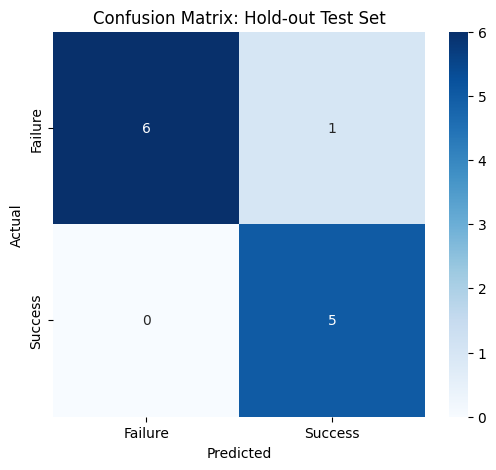

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for hold-out set
cm_holdout = confusion_matrix(y_test_holdout, y_pred_holdout)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Failure', 'Success'], yticklabels=['Failure', 'Success'])
plt.title('Confusion Matrix: Hold-out Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

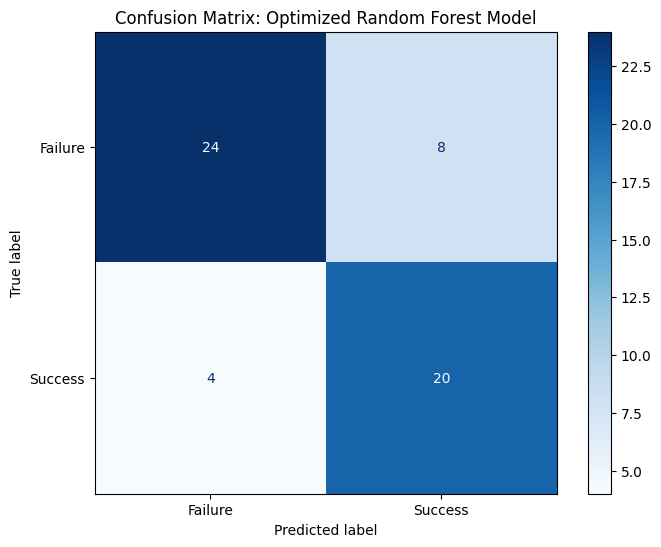

Correct Failures (True Negatives): 24
Incorrect Successes (False Positives): 8
Incorrect Failures (False Negatives): 4
Correct Successes (True Positives): 20


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix using actual 'y' and predicted 'y_pred_optimized'
cm = confusion_matrix(y, y_pred_optimized)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix: Optimized Random Forest Model')
plt.show()

# Print summary of results
tn, fp, fn, tp = cm.ravel()
print(f'Correct Failures (True Negatives): {tn}')
print(f'Incorrect Successes (False Positives): {fp}')
print(f'Incorrect Failures (False Negatives): {fn}')
print(f'Correct Successes (True Positives): {tp}')

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report using the optimized model predictions
report = classification_report(y, y_pred_optimized, target_names=['Failure', 'Success'])

print("Classification Report: Optimized Random Forest Model")
print("-" * 55)
print(report)

Classification Report: Optimized Random Forest Model
-------------------------------------------------------
              precision    recall  f1-score   support

     Failure       0.86      0.75      0.80        32
     Success       0.71      0.83      0.77        24

    accuracy                           0.79        56
   macro avg       0.79      0.79      0.78        56
weighted avg       0.80      0.79      0.79        56



In [ ]:
import plotly.express as px

# Create a box plot to compare payload mass distributions across different launch sites
fig = px.box(spacex_df,
             x='Launch Site',
             y='Payload Mass (kg)',
             color='Launch Site',
             title='Payload Mass Distribution by Launch Site',
             labels={'Payload Mass (kg)': 'Payload Mass (kg)'},
             points='all')

# Update layout for better readability
fig.update_layout(xaxis_title='Launch Site', yaxis_title='Payload Mass (kg)')
fig.show()